In [2]:
# Physical AI Demo in Jupyter Notebook
# Concept: Sense -> Perceive -> Decide -> Act -> Feedback

import numpy as np
import matplotlib.pyplot as plt
import time
from IPython.display import clear_output

In [3]:
# ---------------------------------------------------
# 1. Environment
# ---------------------------------------------------

GRID_SIZE = 20

# Robot starting position
robot = np.array([1, 1])

# Target position
target = np.array([18, 18])

# Obstacles
obstacles = [
    (5, 5), (5, 6), (5, 7),
    (10, 10), (10, 11), (10, 12),
    (14, 15), (15, 15), (16, 15)
]

In [6]:
# ---------------------------------------------------
# 2. Sensor Function
# ---------------------------------------------------

def sense_environment(robot_position):
    """
    Simulates robot sensors.
    Returns nearby obstacle information.
    """

    sensor_range = 2

    nearby_obstacles = []

    for obs in obstacles:
        distance = np.linalg.norm(
            robot_position - np.array(obs)
        )

        if distance <= sensor_range:
            nearby_obstacles.append(obs)

    return nearby_obstacles

In [7]:
# ---------------------------------------------------
# 3. Perception Layer
# ---------------------------------------------------

def perceive(robot_position):
    """
    Converts sensor data into meaningful information.
    """

    detected_obstacles = sense_environment(robot_position)

    distance_to_target = np.linalg.norm(
        target - robot_position
    )

    return {
        "robot_position": robot_position.copy(),
        "detected_obstacles": detected_obstacles,
        "distance_to_target": distance_to_target
    }

In [8]:
# ---------------------------------------------------
# 4. Decision / Planning Layer
# ---------------------------------------------------

def plan_next_move(state):
    """
    Simple AI planner.

    Robot tries moves that bring it closer to target
    while avoiding obstacles.
    """

    robot_position = state["robot_position"]

    possible_moves = [
        np.array([1, 0]),    # right
        np.array([-1, 0]),   # left
        np.array([0, 1]),    # up
        np.array([0, -1])    # down
    ]

    best_move = None
    best_distance = float("inf")

    for move in possible_moves:

        new_position = robot_position + move

        # Check world boundaries
        if (
            new_position[0] < 0
            or new_position[0] >= GRID_SIZE
            or new_position[1] < 0
            or new_position[1] >= GRID_SIZE
        ):
            continue

        # Avoid obstacle
        if tuple(new_position) in obstacles:
            continue

        distance = np.linalg.norm(
            target - new_position
        )

        if distance < best_distance:
            best_distance = distance
            best_move = move

    return best_move

In [9]:
# ---------------------------------------------------
# 5. Action Layer
# ---------------------------------------------------

def act(robot_position, move):
    """
    Simulates motor / actuator movement.
    """

    if move is not None:
        robot_position += move

    return robot_position

In [10]:
# ---------------------------------------------------
# 6. Visualization
# ---------------------------------------------------

def draw_world(robot_position, step):

    clear_output(wait=True)

    plt.figure(figsize=(7, 7))

    # Plot obstacles
    for obs in obstacles:
        plt.scatter(
            obs[0],
            obs[1],
            marker="s",
            s=200
        )

    # Plot robot
    plt.scatter(
        robot_position[0],
        robot_position[1],
        s=300,
        label="Robot"
    )

    # Plot target
    plt.scatter(
        target[0],
        target[1],
        marker="*",
        s=400,
        label="Target"
    )

    plt.xlim(-1, GRID_SIZE)
    plt.ylim(-1, GRID_SIZE)

    plt.grid(True)

    plt.title(
        f"Physical AI Simulation - Step {step}"
    )

    plt.legend()

    plt.show()

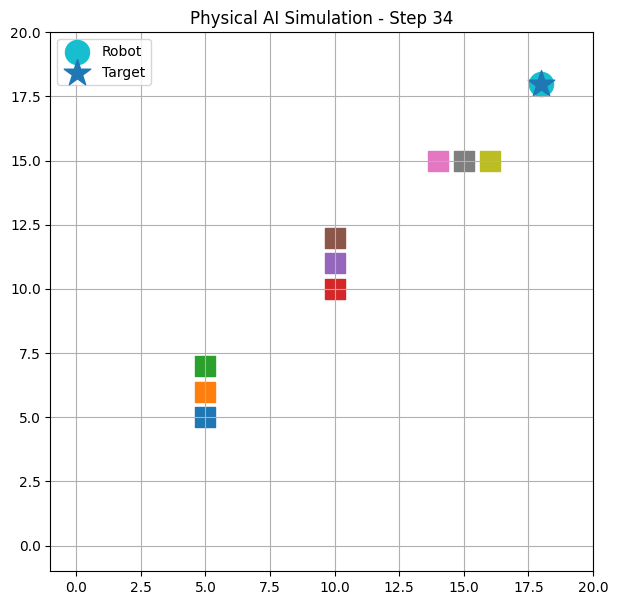

In [11]:
# ---------------------------------------------------
# 7. Physical AI Feedback Loop
# ---------------------------------------------------

MAX_STEPS = 100

for step in range(MAX_STEPS):

    # SENSE + PERCEIVE
    state = perceive(robot)

    print("Step:", step)
    print("Robot Position:", state["robot_position"])
    print("Detected Obstacles:", state["detected_obstacles"])
    print(
        "Distance to Target:",
        round(state["distance_to_target"], 2)
    )

    # Check goal
    if np.array_equal(robot, target):
        print("\nTarget reached!")
        draw_world(robot, step)
        break

    # DECIDE / PLAN
    move = plan_next_move(state)

    # ACT
    robot = act(robot, move)

    # VISUAL FEEDBACK
    draw_world(robot, step)

    time.sleep(0.2)